# Exercises Chapter 2
## Exersice 1

In [1]:
# Import dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import *
from sklearn.preprocessing import StandardScaler
import numpy as np
from idlmam import *

/home/efrain/Documents/Training-AI-ML-DL/Inside_Deep_Learning/idlmam.py:7: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


<Axes: >

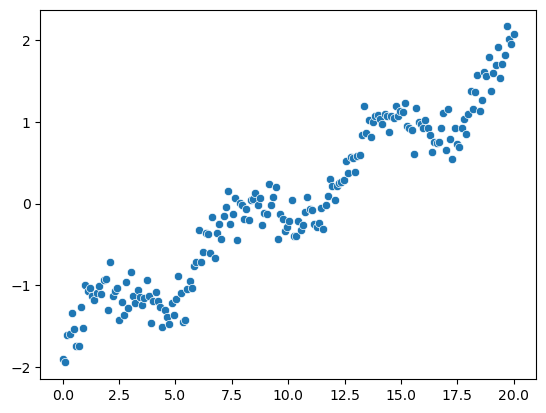

In [14]:
# Data and standardscaler function
X = np.linspace(0, 20, 200)
y = X + np.sin(X)*2 + np.random.normal(size=X.shape)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(y.reshape(-1,1))
sns.scatterplot(x=X, y=scaled_data[:,0])

<Axes: >

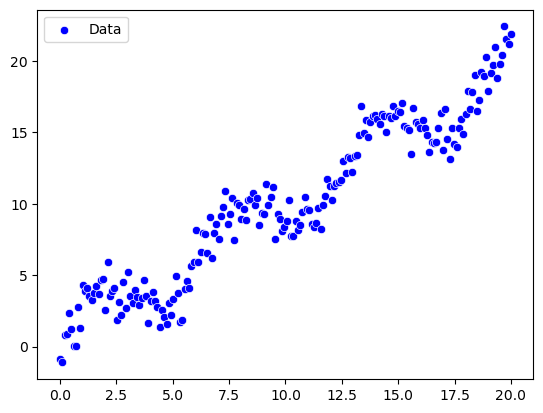

In [15]:
# Plotting values before transformation
sns.scatterplot(x=X, y=y, color='blue', label='Data')

In [20]:
# Simple training loop model

def train_simple_network(model, loss_func, training_loader, epochs=100, device="cpu"):
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

    model.to(device)

    for epoch in tqdm(range(epochs), desc="Epoch"):
        model = model.train()
        running_loss = 0.0

        for inputs, labels in tqdm(training_loader, desc="Batch", leave=False):
            inputs = moveTo(inputs, device)
            labels = moveTo(labels,device)

            optimizer.zero_grad()

            y_hat = model(inputs)

            loss = loss_func(y_hat, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

In [17]:
# Data loader in pytorch

class Simple1DRegressionDataset(Dataset):
    def __init__(self, X, y):
        super(Simple1DRegressionDataset, self).__init__()
        self.X = X.reshape(-1,1)
        self.y = y.reshape(-1,1)

    def __getitem__(self, index):
        return torch.tensor(self.X[index,:], dtype=torch.float32), torch.tensor(self.y[index], dtype=torch.float32)
    
    def __len__(self):
        return self.X.shape[0]

In [97]:
# Define the model architecture
model_ex1 = nn.Sequential(
    nn.Linear(1, 30),
    nn.Tanh(),
    nn.Linear(30, 60),
    nn.Tanh(),
    nn.Linear(60, 30),
    nn.Tanh(),
    nn.Linear(30, 1)
)

In [98]:
# hyperparameters

loss_function = nn.MSELoss()
device = torch.device("cpu")
training_loader = DataLoader(Simple1DRegressionDataset(X, y), shuffle=True)
epochs = 500


In [24]:
# train the model
train_simple_network(model_ex1, loss_function, training_loader, epochs=epochs)

Epoch: 100%|██████████| 500/500 [01:07<00:00,  7.45it/s]


In [25]:
with torch.no_grad():
    Y_pred = model_ex1(torch.tensor(X.reshape(-1,1), dtype=torch.float32)).cpu().numpy()

<Axes: >

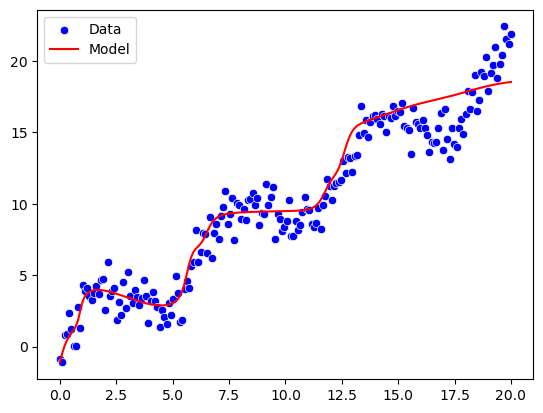

In [26]:
# Plotting results
sns.scatterplot(x=X, y=y, color='blue', label='Data')
sns.lineplot(x=X, y=Y_pred.ravel(), color='red', label='Model')

In [27]:
# hyperparameters

loss_function = nn.MSELoss()
device = torch.device("cpu")
training_loader = DataLoader(Simple1DRegressionDataset(X, scaled_data), shuffle=True)
epochs = 500


In [28]:
# train the model
train_simple_network(model_ex1, loss_function, training_loader, epochs=epochs)

Epoch: 100%|██████████| 500/500 [01:09<00:00,  7.18it/s]


In [65]:
with torch.no_grad():
    Y_pred = model_ex1(torch.tensor(X.reshape(-1,1), dtype=torch.float32)).cpu().numpy()

<Axes: >

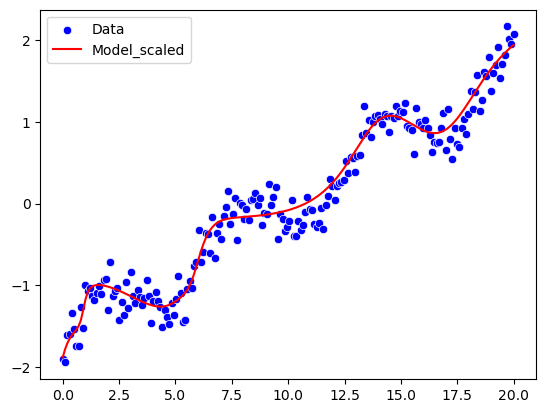

In [66]:
# Plotting results
sns.scatterplot(x=X, y=scaled_data[:,0], color='blue', label='Data')
sns.lineplot(x=X, y=Y_pred.ravel(), color='red', label='Model_scaled')

## Exercise 2
Wrapper function to use area under the curve calculation from scikit-learn

Using AI's help (perplexity claude sonnet 4.5)

In [71]:
from sklearn.metrics import auc

#   Wrapper function
def area_under_curve(x, y):
    area = auc(X, y.flatten())
    
    return area


In [72]:
area_under_curve(X, Y_pred)

0.6930379867553711

## Exercise 3
New trainig model function with a resumer checkpoint for epochs.

In [10]:
def train_simple_network_better(model, loss_func, train_loader, test_loader=None, score_funcs=None, 
                                epochs=300, device='cpu', checkpoint_file=None, resume_from_checkpoint=None,
                                checkpoint_every_x=None):
    
    """Train simple neural networks
    
    Keyword arguments:
    model -- the PyTorch model / "Module" to train
    loss_func -- the loss function that takes in batch in two arguments, the model outputs and the labels, and returns a score
    train_loader -- PyTorch DataLoader object that returns tuples of (input, label) pairs. 
    test_loader -- Optional PyTorch DataLoader to evaluate on after every epoch
    score_funcs -- A dictionary of scoring functions to use to evalue the performance of the model
    epochs -- the number of training epochs to perform
    device -- the compute lodation to perform training
    checkpoint_file -- path to save checkpoint at the end of training
    resume_from_checkpoint -- path to load checkpoint from to resume training
    checkpoint_every_x -- save checkpoint every X epochs (None to only save at end)
    
    """
    to_track = ["epoch", "total time", "train loss"]
    if test_loader is not None:
        to_track.append("test loss")
    for eval_score in score_funcs:
        to_track.append("train " + eval_score )
        if test_loader is not None:
            to_track.append("test " + eval_score )
        
    total_train_time = 0 #How long have we spent in the training loop? 
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []
    
    #SGD is Stochastic Gradient Decent.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.0001)
    
    # Initialize starting epoch
    start_epoch = 0
    
    # Load checkpoint if provided
    if resume_from_checkpoint is not None:
        checkpoint = torch.load(resume_from_checkpoint, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1  # Resume from next epoch
        results = checkpoint.get('results', results)  # Restore previous results
        total_train_time = results["total time"][-1] if results["total time"] else 0
        print(f"Resuming from epoch {start_epoch}, previous training time: {total_train_time:.2f}s")
    
    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device)
    
    # Move optimizer state to device (important when loading on GPU)
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)

    for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):
        model = model.train()#Put our model in training mode
        
        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, prefix="train", desc="Training")

        results["total time"].append( total_train_time )
        results["epoch"].append( epoch )
        
        if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", desc="Testing")
        
        # Save checkpoint every X epochs if specified
        if checkpoint_every_x is not None and (epoch + 1) % checkpoint_every_x == 0:
            checkpoint_path = checkpoint_file if checkpoint_file else f'checkpoint_epoch_{epoch}.tar'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'results' : results
                }, checkpoint_path)
            print(f"Checkpoint saved at epoch {epoch}")
                    
    # Save final checkpoint if specified
    if checkpoint_file is not None:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'results' : results
            }, checkpoint_file)
        
    return pd.DataFrame.from_dict(results)


In [ ]:
# test the model
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

restoration_test = train_simple_network_better(model_ex1, 
                                               loss_function, 
                                               training_loader, 
                                               checkpoint_file='restore.pt', 
                                               epochs=150,
                                               score_funcs={'Acc': accuracy_score, 'F1': f1_score},
                                               checkpoint_every_x=50)

In [111]:
restoration_test_1 = train_simple_network_better(model_ex1, 
                                               loss_function, 
                                               training_loader, 
                                               checkpoint_file='restore.pt',
                                               resume_from_checkpoint='restore.pt', 
                                               epochs=150,
                                               score_funcs={'Acc': accuracy_score, 'F1': f1_score},
                                               checkpoint_every_x=50)

Resuming from epoch 100, previous training time: 13.57s


Epoch: 100%|██████████| 50/50 [00:06<00:00,  7.39it/s]

Checkpoint saved at epoch 149


## Exercise 7 - Breast Cancer Dataset (Scikit-learn)

In [2]:
#import dependencies and the dataset from sklearn

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.datasets import load_breast_cancer
 

In [3]:
BC_data = load_breast_cancer()

# Create dataframe
df_BC = pd.DataFrame(np.c_[BC_data['data'], BC_data['target']],
                     columns=np.append(BC_data['feature_names'],['target']))

In [4]:
# Display basic information
print("Dataset shape:", df_BC.shape)
print("\nFirst few rows:")
print(df_BC.head())
print("\nDataset statistics:")
print(df_BC.describe())
print("\nTarget distribution:")
print(df_BC['target'].value_counts())

Dataset shape: (569, 31)

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  wor

In [19]:
# Convert to PyTorch tensrdataset
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = BC_data['data']  # Shape: (569, 30)
y = BC_data['target']  # Shape: (569,)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize data with standardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).long()
X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

X_train_tensor_st = torch.from_numpy(X_train_scaled).float()
X_test_tensor_st = torch.from_numpy(X_test_scaled).float()

# Convert numpy arrays to PyTorch tensors from scaled data
X_train_tensor_s = torch.from_numpy(X_train_scaled).float()
X_test_tensor_s = torch.from_numpy(X_test_scaled).float()


# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_dataset_s = TensorDataset(X_train_tensor_s, y_train_tensor)
test_dataset_s = TensorDataset(X_test_tensor_s, y_test_tensor)



In [20]:

# Create DataLoaders
train_loader = DataLoader(train_dataset_s, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset_s, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of batches in train_loader: {len(train_loader)}")


Training samples: 455
Test samples: 114
Number of batches in train_loader: 15


In [7]:
# Define model network
model_BC = nn.Sequential(
    nn.Linear(30, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 2)
)

In [27]:
model_BC_2 = nn.Sequential(
    nn.Linear(30, 64),
    nn.BatchNorm1d(64),  # Add batch normalization
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 2)
)

In [21]:
# Hyperparameters:
loss_func = nn.CrossEntropyLoss()
scores = {'Acc': accuracy_score, 'F1': f1_score}
epochs = 1000
device='cpu'

In [28]:
results_BC = train_simple_network_better(model_BC_2,
                                         loss_func,
                                         train_loader,
                                         test_loader,
                                         epochs=epochs, 
                                         checkpoint_file='model_BC.pt',
                                         score_funcs=scores,
                                         device=device)

Epoch: 100%|██████████| 1000/1000 [01:53<00:00,  8.82it/s]


<Axes: xlabel='epoch', ylabel='train Acc'>

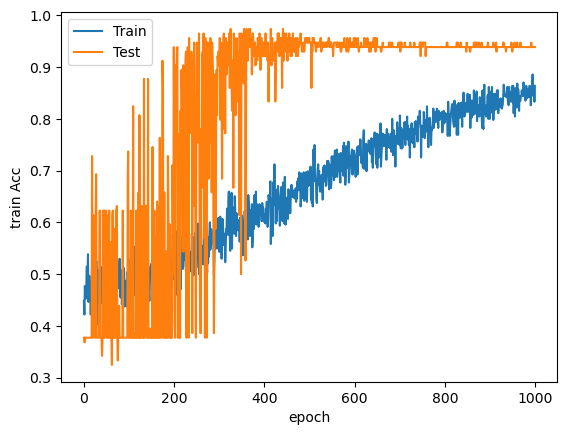

In [12]:
sns.lineplot(x='epoch', y='train Acc', data=results_BC, label='Train')
sns.lineplot(x='epoch', y='test Acc', data=results_BC, label="Test")

<Axes: xlabel='total time', ylabel='train F1'>

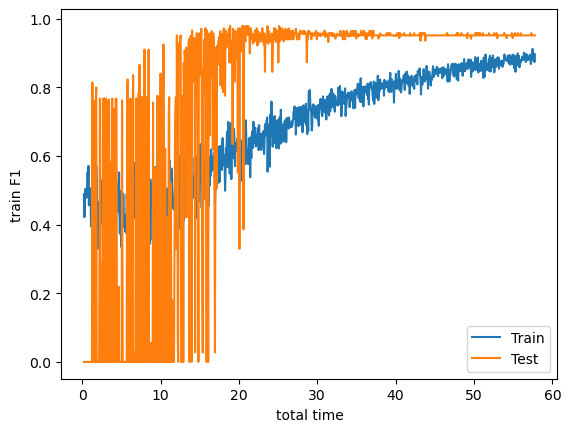

In [13]:
sns.lineplot(x='total time', y='train F1', data=results_BC, label='Train')
sns.lineplot(x='total time', y='test F1', data=results_BC, label="Test")

<Axes: xlabel='epoch', ylabel='train Acc'>

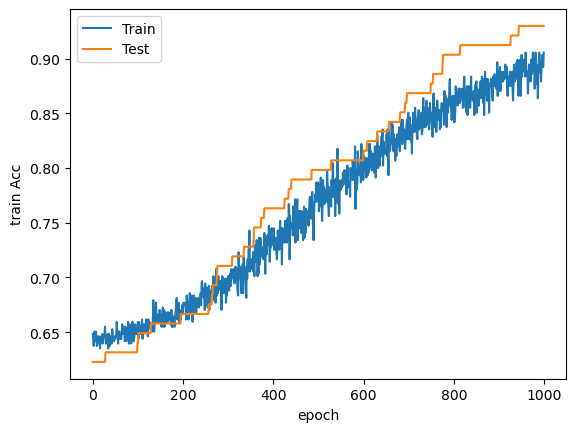

In [23]:
# Transformed data:
sns.lineplot(x='epoch', y='train Acc', data=results_BC, label='Train')
sns.lineplot(x='epoch', y='test Acc', data=results_BC, label="Test")

<Axes: xlabel='total time', ylabel='train F1'>

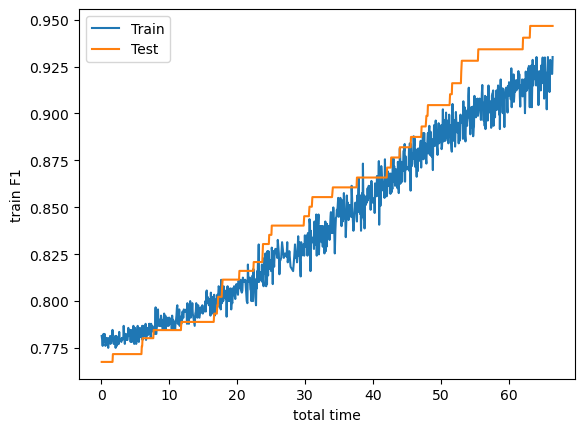

In [26]:
# Transformed data
sns.lineplot(x='total time', y='train F1', data=results_BC, label='Train')
sns.lineplot(x='total time', y='test F1', data=results_BC, label="Test")

Text(0.5, 1.0, 'Model BatchNorm')

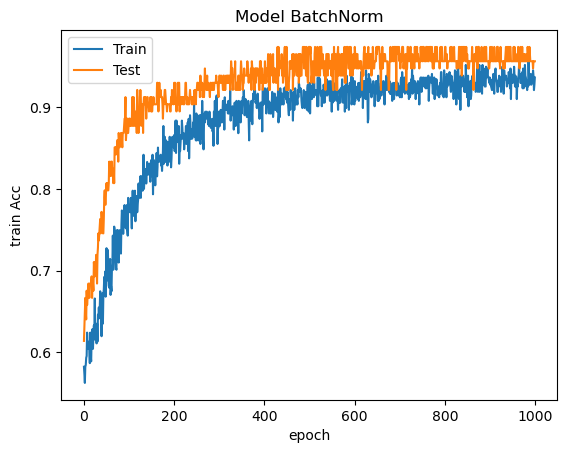

In [29]:
# Transformed data:
sns.lineplot(x='epoch', y='train Acc', data=results_BC, label='Train')
sns.lineplot(x='epoch', y='test Acc', data=results_BC, label="Test")
plt.title('Model BatchNorm')

Text(0.5, 1.0, 'Model BatchNorm')

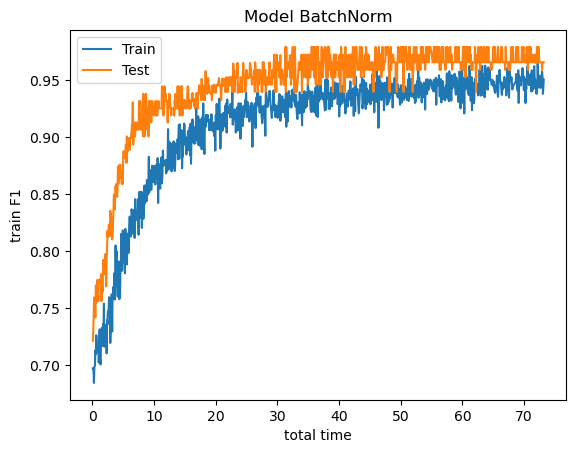

In [30]:
sns.lineplot(x='total time', y='train F1', data=results_BC, label='Train')
sns.lineplot(x='total time', y='test F1', data=results_BC, label="Test")
plt.title('Model BatchNorm')